[*********************100%***********************]  1 of 1 completed

Téléchargement de l'historique long (depuis 1990)...
Lancement de 100000 simulations (Bootstrap)...



--- STATISTIQUES DES SIMULATIONS ANNUELLES ---
Rendement moyen S&P 500 : 9.71%
Rendement moyen Buffer  : 5.82%
Volatilité des années S&P 500 : 20.16%
Volatilité des années Buffer  : 6.74%
Pire scénario S&P 500 : -53.21%
Pire scénario Buffer  : -38.21%

Probabilité de finir l'année en négatif (S&P 500) : 33.8%
Probabilité de finir l'année en négatif (Buffer)  : 9.5%

Remarque pour l'analyse :
Observez le pic massif généré par le Cap sur la courbe bleue. C'est le 'coût d'opportunité' rendu visible : tous les excellents scénarios gris sont écrasés et ramenés au niveau du plafond.


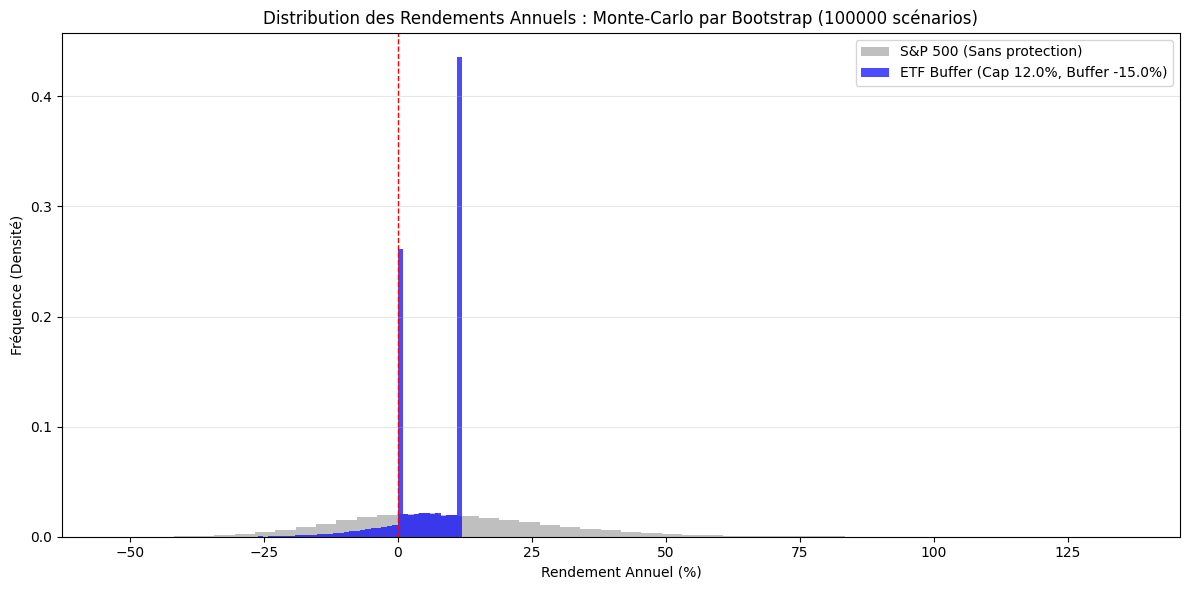

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# MONTE-CARLO PAR BOOTSTRAP (Tirage Historique)
# Objectif : Simuler 1000 chemins annuels basés sur les vrais rendements du S&P500
# pour voir la distribution des gains d'un ETF Buffer vs un investissement direct.

# 1. Récupération de l'historique long terme du S&P 500
print("Téléchargement de l'historique long (depuis 1990)...")
sp500 = yf.download('^GSPC', start='1990-01-01', end='2024-01-01')['Close']
daily_returns = sp500.pct_change().dropna()

# 2. Paramètres de la simulation
N_SIMULATIONS = 100000
DAYS_IN_YEAR = 252
BUFFER_LEVEL = -0.15 # Protège les premiers 15% de baisse
CAP_LEVEL = 0.12     # Plafonne les gains à 12%

# 3. Fonction de Payoff du Buffer
def apply_buffer_payoff(underlying_return, buffer_pct, cap_pct):
    if underlying_return > 0:
        return min(underlying_return, cap_pct)
    else:
        return min(0, underlying_return - buffer_pct)

# 4. Exécution du Bootstrap
print(f"Lancement de {N_SIMULATIONS} simulations (Bootstrap)...")
simulated_sp500_annual_returns = []
simulated_buffer_annual_returns = []

returns_array = daily_returns.values.flatten()

for i in range(N_SIMULATIONS):
    # Tirage aléatoire avec remise de 252 jours de rendements parmi l'historique
    random_days = np.random.choice(returns_array, size=DAYS_IN_YEAR, replace=True)
    
    # Calcul du rendement cumulé sur l'année simulée
    annual_return_sp500 = np.prod(1 + random_days) - 1
    simulated_sp500_annual_returns.append(annual_return_sp500)
    
    # Application de la structure optionnelle sur le rendement final de l'année
    annual_return_buffer = apply_buffer_payoff(annual_return_sp500, BUFFER_LEVEL, CAP_LEVEL)
    simulated_buffer_annual_returns.append(annual_return_buffer)

# 5. Analyse des résultats
sp500_sim_series = pd.Series(simulated_sp500_annual_returns)
buffer_sim_series = pd.Series(simulated_buffer_annual_returns)

print("\n--- STATISTIQUES DES SIMULATIONS ANNUELLES ---")
print(f"Rendement moyen S&P 500 : {sp500_sim_series.mean()*100:.2f}%")
print(f"Rendement moyen Buffer  : {buffer_sim_series.mean()*100:.2f}%")
print(f"Volatilité des années S&P 500 : {sp500_sim_series.std()*100:.2f}%")
print(f"Volatilité des années Buffer  : {buffer_sim_series.std()*100:.2f}%")
print(f"Pire scénario S&P 500 : {sp500_sim_series.min()*100:.2f}%")
print(f"Pire scénario Buffer  : {buffer_sim_series.min()*100:.2f}%")

# Probabilités
prob_loss_sp500 = (sp500_sim_series < 0).mean() * 100
prob_loss_buffer = (buffer_sim_series < 0).mean() * 100
print(f"\nProbabilité de finir l'année en négatif (S&P 500) : {prob_loss_sp500:.1f}%")
print(f"Probabilité de finir l'année en négatif (Buffer)  : {prob_loss_buffer:.1f}%")

# 6. Visualisation (Histogrammes superposés)
plt.figure(figsize=(12, 6))

# Histogramme S&P 500 (Gris)
plt.hist(sp500_sim_series * 100, bins=50, alpha=0.5, color='gray', label='S&P 500 (Sans protection)', density=True)

# Histogramme ETF Buffer (Bleu)
# Attention: le Cap va créer un pic massif à +12% et le Buffer un "mur" à 0%
plt.hist(buffer_sim_series * 100, bins=50, alpha=0.7, color='blue', label=f'ETF Buffer (Cap {CAP_LEVEL*100}%, Buffer {BUFFER_LEVEL*100}%)', density=True)

plt.title('Distribution des Rendements Annuels : Monte-Carlo par Bootstrap (100000 scénarios)')
plt.xlabel('Rendement Annuel (%)')
plt.ylabel('Fréquence (Densité)')
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# plt.show()
print("\nRemarque pour l'analyse :")
print("Observez le pic massif généré par le Cap sur la courbe bleue. C'est le 'coût d'opportunité' rendu visible : tous les excellents scénarios gris sont écrasés et ramenés au niveau du plafond.")